# Tsyganenko model geopack magnetic field calculation
### in relation to INTEGRAL's position in space and time


## Google Colab exclusive part starts here

The script below will automatically download the orbit data file from Google Drive and unpack it.

In [10]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Detected Google Colab environment. Setting up workspace...")

    !pip install gdown
    import gdown

    file_url = "https://drive.google.com/file/d/1bRX18plirSk3uK9FhHBZf0QJBVPu3O4e/view?usp=sharing"
    output_file = "orbit_data.h5"

    # download orbit data
    gdown.download(file_url, output_file, quiet=False, fuzzy=True)

    # install required libraries
    !pip install geopack spacepy

else:
    print("Running in local environment. Skipping Colab-only setup.")

Running in local environment. Skipping Colab-only setup.


## Google Colab exclusive part ends here

---

## Notebook description

This notebook computes modeled magnetic field vector values at the position and time of the INTEGRAL spacecraft using Tsyganenko's TS05 model, incorporating local perturbations due to space weather conditions from the OMNI database. Additional details regarding the model can be found at the following resource:

https://geo.phys.spbu.ru/~tsyganenko/empirical-models/magnetic_field/ts05

#### REQUIRED INPUT:
 - INTEGRAL orbit position data in HDF5 format [`orbit_data.h5`] (generated by `01_fetch_orbit_data.ipynb`)
 - Tsyganenko model input files in .dat text format [XXXX_OMNI_5m_with_TS05_variables.dat]. These files are automatically retrieved by the script for the years 2002 to 20XX (the previous year). For more recent data, users must manually generate the input file. A sample file is provided for the first half of 2025 - the download link is included in the notebook below.

#### OUTPUT:
 - An HDF5 file containing a table of modeled magnetic field vector components (XYZ), magnitude, and geocentric distance for INTEGRAL [`magfield_data_own.hdf5`]
 - Plots showcasing the generated magnetic field vector values

If you're getting a `ModuleNotFoundError` or any similiar one after running the below line of code - report to the person responsible for the notebook.

In [11]:
import os
import time
import requests
import zipfile


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from datetime import datetime, timedelta
from pathlib import Path
from geopack import geopack, t04, t89
from spacepy import coordinates as coord
from spacepy import time as spt


Currently dates from 2002-10-17 05:45:00 to 2025-02-08 16:35:00 are supported for INTEGRAL - due to orbit data availability.

In [12]:
startyear = 2005
endyear = 2005

START_DATE = datetime(startyear, 1, 1)
END_DATE = datetime(endyear, 12, 31)

Download the official input data from Tsyganenko's website - contains OMNI data but also pre-calculated input values, so we need this particular dataset.

Running the cell below will download files (12,5 MiB per chosen year, max 275 MiB)  of files to your computer, if you don't have it downloaded yet.

⚠️ WARNING 2! The data for 2025 is not available as of now - only for finished years. Input data for the year 2025 until July 31th has been created using Fortran scripts from Tsyganenko's website and is available for download here - put it manually in the `tsygan_input` directory if you want to use endyear=2025

https://drive.google.com/file/d/1Vk0AG1AiDyGyzt5wzY1sYC5T61phi6VJ/view?usp=sharing

In [13]:
chunk_size = 256

#info about model: https://geo.phys.spbu.ru/~tsyganenko/models/ts05/1995_OMNI_5m_with_TS05_variables.dat
dirpath = Path("./tsygan_input")
dirpath.mkdir(exist_ok=True)

url = "https://geo.phys.spbu.ru/~tsyganenko/TS05_data_and_stuff/"
names = [f"{year}_OMNI_5m_with_TS05_variables.zip" for year in range(startyear, endyear+1)]

for filename in names:
    zip_path = dirpath / filename
    dat_path = dirpath / filename.replace(".zip", ".dat")

    if dat_path.exists():
        print(f"Skipping {dat_path.name} (already extracted).")
        continue

    if not zip_path.exists():
        print(f"Downloading {filename}...")
        req = requests.get(url + filename, stream=True, verify=False)

        try:
            with open(zip_path, "wb") as file:
                for chunk in req.iter_content(chunk_size=chunk_size):
                    if chunk:
                        file.write(chunk)
            print(f"Download successful: {filename}")
        except OSError as e:
            print(f"Download failed for {filename}: {e}")
            continue

    if not dat_path.exists():
        try:
            with zipfile.ZipFile(zip_path, "r") as zip_ref:
                zip_ref.extractall(dirpath)
            print(f"Extracted {filename} -> {dat_path.name}")
        except zipfile.BadZipFile:
            print(f"Corrupted zip file: {zip_path}")

Skipping 2005_OMNI_5m_with_TS05_variables.dat (already extracted).


Preparation dataset - we get the data that will be required to reconstruct vector data about INTEGRAL's travels

In [14]:
df_prep_integral_raw = pd.read_hdf('orbit_data.h5', key='df')


df_prep_integral_raw = df_prep_integral_raw.set_index("time")
df_prep_integral_raw = df_prep_integral_raw[~df_prep_integral_raw.index.duplicated(keep='first')]

datetime_index = pd.date_range(start=df_prep_integral_raw.index.min(),
                                end=df_prep_integral_raw.index.max(),
                                freq="5min")

df_prep_integral = pd.merge(df_prep_integral_raw, df_prep_integral_raw.asfreq('5min'), left_index=True, right_index=True, how='outer').interpolate(method='time')
df_prep_integral = df_prep_integral.reindex(datetime_index)
df_prep_integral.index = df_prep_integral.index.round('min')

#filter for date range

df_prep_integral = df_prep_integral[(df_prep_integral.index >= START_DATE) & (df_prep_integral.index <= END_DATE)]

df_prep_integral = df_prep_integral[['x_j2000_x', 'y_j2000_x', 'z_j2000_x', 'distance_x']]

df_prep_integral = df_prep_integral.rename(columns={
    'x_j2000_x': 'x_j2000',
    'y_j2000_x': 'y_j2000',
    'z_j2000_x': 'z_j2000',
    'distance_x': 'distance'
})

df_prep_integral['distance'] = df_prep_integral['distance'] / 6371.2

df_prep_integral.head(10)

,x_j2000,y_j2000,z_j2000,distance
2005-01-01 00:00:00,6714.425206,613.215935,-17844.064537,2.995152
2005-01-01 00:05:00,7236.651257,2263.484721,-17227.499170,2.956389
2005-01-01 00:10:00,7720.694847,3901.435960,-16520.470448,2.929479
2005-01-01 00:15:00,8163.251104,5518.379335,-15724.690394,2.914815
2005-01-01 00:20:00,8559.904391,7104.380932,-14840.343069,2.913056
2005-01-01 00:25:00,8911.304819,8653.185600,-13877.056610,2.923462
2005-01-01 00:30:00,9208.496198,10149.518881,-12829.112075,2.947782
2005-01-01 00:35:00,9456.183658,11590.963103,-11712.580922,2.984224
2005-01-01 00:40:00,9655.576870,12973.031535,-10536.436259,3.032007
2005-01-01 00:45:00,9807.602063,14291.461448,-9308.576549,3.090464


Finally we calculate the xyz positions of INTEGRAL in time - with GSE coordinates (used most often by us as of now) and GSM coordinates, which are required for further calculations

In [15]:
# Prepare inputs
ticks = spt.Ticktock(pd.to_datetime(df_prep_integral.index).to_pydatetime(), 'UTC')
coords = df_prep_integral[['x_j2000', 'y_j2000', 'z_j2000']].values
coords_re = coords / 6371.2  # Convert to Earth radii (Re)


cvals = coord.Coords(coords_re, 'ECI2000', 'car')
cvals.ticks = ticks
cvals.use_irbem = True

# Convert all J2000 -> GSM in one go
coords_gsm_re = cvals.convert('GSM', 'car')

# Store back into dataframe
df_prep_integral['x_gsm_re'] = coords_gsm_re.x
df_prep_integral['y_gsm_re'] = coords_gsm_re.y
df_prep_integral['z_gsm_re'] = coords_gsm_re.z



df_prep_integral.head()

,x_j2000,y_j2000,z_j2000,distance,x_gsm_re,y_gsm_re,z_gsm_re
2005-01-01 00:00:00,6714.425206,613.215935,-17844.064537,2.995152,1.201988,1.510465,-2.288617
2005-01-01 00:05:00,7236.651257,2263.484721,-17227.499170,2.956389,0.945695,1.638613,-2.269003
2005-01-01 00:10:00,7720.694847,3901.435960,-16520.470448,2.929479,0.684509,1.757985,-2.237858
2005-01-01 00:15:00,8163.251104,5518.379335,-15724.690394,2.914815,0.419667,1.867816,-2.195103
2005-01-01 00:20:00,8559.904391,7104.380932,-14840.343069,2.913056,0.152458,1.967092,-2.140409


Loading the Tsyganenko's files - the dictionary has been generated based on https://geo.phys.spbu.ru/~tsyganenko/models/ts05/Data_format

In [16]:
OMNI_5min_TS05_names = [
    "Year",                   # IYEAR
    "Day",                    # IDAY
    "Hour",                   # IHOUR
    "Minute",                 # MIN

    "BX_GSM",                 # BXGSM, nT
    "BY_GSM",                 # BYGSM, nT
    "BZ_GSM",                 # BZGSM, nT

    "VX_GSE",                 # VXGSE, km/s
    "VY_GSE",                 # VYGSE, km/s
    "VZ_GSE",                 # VZGSE, km/s

    "Proton_Density",         # DEN, particles/cc
    "Proton_Temperature",     # TEMP, K

    "SYM_H",                  # SYMH index, nT

    "IMF_Flag",               # IMFFLAG (data availability)
    "SW_Flag",                # ISWFLAG (data availability)

    "Dipole_Tilt_Rad",        # TILT, radians
    "Ram_Pressure_nPa",       # Pdyn, nPa

    # TS05 model driving variables:
    "W1",
    "W2",
    "W3",
    "W4",
    "W5",
    "W6"
]

filepaths = ["./tsygan_input/" + f for f in os.listdir("./tsygan_input")]

#filter for .dat files only

filepaths = [f for f in filepaths if f.endswith(".dat")]

#naively filter the filepaths to only include files from the specified years
filepaths = [
    f for f in filepaths 
    if any(str(year) in f for year in range(startyear, endyear + 1))
]

globcount = 0

def myread(path):
    #print("Reading:", path)
    df_inner = pd.read_table(path, sep=r'\s+', names=OMNI_5min_TS05_names)
    if path == "./tsygan_input/2010_OMNI_5m_with_TS05_variables.dat":
        df_inner.iloc[:, 15] = pd.to_numeric(df_inner.iloc[:, 15], errors='coerce')
        df_inner.iloc[:, 20] = pd.to_numeric(df_inner.iloc[:, 20], errors='coerce')
    return df_inner

input_df = pd.concat(map(myread, filepaths))


pd.set_option('display.max_columns', None)


input_df.head()

,Year,Day,Hour,Minute,BX_GSM,BY_GSM,BZ_GSM,VX_GSE,VY_GSE,VZ_GSE,Proton_Density,Proton_Temperature,SYM_H,IMF_Flag,SW_Flag,Dipole_Tilt_Rad,Ram_Pressure_nPa,W1,W2,W3,W4,W5,W6
0,2005,1,0,40,-2.15,2.37,1.76,-438.9,-8.9,15.4,5.31,89609.0,-2.0,1,1,-0.4778,1.99,0.0,0.0,0.0,0.0,0.0,0.0
1,2005,1,0,45,-2.37,2.03,0.69,-434.1,19.3,29.3,6.03,87492.0,-1.0,1,1,-0.4814,2.23,0.0,0.0,0.0,0.0,0.0,0.0
2,2005,1,0,50,-2.74,3.44,4.39,-433.9,-19.9,0.3,5.45,88410.0,0.0,1,1,-0.4849,1.99,0.0,0.0,0.0,0.0,0.0,0.0
3,2005,1,0,55,-3.82,3.56,3.40,-427.8,-18.1,13.0,5.32,111721.0,-1.0,1,1,-0.4884,1.89,0.0,0.0,0.0,0.0,0.0,0.0
4,2005,1,1,0,-2.73,3.75,3.86,-428.8,-16.6,6.9,4.84,115356.0,-1.0,1,1,-0.4918,1.73,0.0,0.0,0.0,0.0,0.0,0.0


Convert to a good datetime format

In [17]:
input_df['Year'] = pd.to_datetime(input_df['Year'].astype(str), format='%Y') + \
                 pd.to_timedelta(input_df['Day'] - 1, unit='D') + \
                 pd.to_timedelta(input_df['Hour'], unit='h') + \
                 pd.to_timedelta(input_df['Minute'], unit='m')

#change name of 'Year' column to 'Time'
input_df.rename(columns={'Year': 'time'}, inplace=True)
input_df.drop(columns=['Day', 'Hour', 'Minute'], inplace=True)
input_df.sort_values(by='time', inplace=True)
input_df = input_df.set_index('time')

input_df.head()

,BX_GSM,BY_GSM,BZ_GSM,VX_GSE,VY_GSE,VZ_GSE,Proton_Density,Proton_Temperature,SYM_H,IMF_Flag,SW_Flag,Dipole_Tilt_Rad,Ram_Pressure_nPa,W1,W2,W3,W4,W5,W6
time,,,,,,,,,,,,,,,,,,,
2005-01-01 00:40:00,-2.15,2.37,1.76,-438.9,-8.9,15.4,5.31,89609.0,-2.0,1,1,-0.4778,1.99,0.0,0.0,0.0,0.0,0.0,0.0
2005-01-01 00:45:00,-2.37,2.03,0.69,-434.1,19.3,29.3,6.03,87492.0,-1.0,1,1,-0.4814,2.23,0.0,0.0,0.0,0.0,0.0,0.0
2005-01-01 00:50:00,-2.74,3.44,4.39,-433.9,-19.9,0.3,5.45,88410.0,0.0,1,1,-0.4849,1.99,0.0,0.0,0.0,0.0,0.0,0.0
2005-01-01 00:55:00,-3.82,3.56,3.40,-427.8,-18.1,13.0,5.32,111721.0,-1.0,1,1,-0.4884,1.89,0.0,0.0,0.0,0.0,0.0,0.0
2005-01-01 01:00:00,-2.73,3.75,3.86,-428.8,-16.6,6.9,4.84,115356.0,-1.0,1,1,-0.4918,1.73,0.0,0.0,0.0,0.0,0.0,0.0


Generate the primary dataset. Note that computational runtime is significant. Processing the entire IREM dataset requires approximately 60-90 minutes.
It is recommended to start with a subset (e.g., 1 year) for initial testing.

Processing 0/104833... 104833 remaining, (0.00%)
Processing 5000/104833... 99833 remaining, (4.77%)
Processing 10000/104833... 94833 remaining, (9.54%)
Processing 15000/104833... 89833 remaining, (14.31%)
Processing 20000/104833... 84833 remaining, (19.08%)
Processing 25000/104833... 79833 remaining, (23.85%)
Processing 30000/104833... 74833 remaining, (28.62%)
Processing 35000/104833... 69833 remaining, (33.39%)
Processing 40000/104833... 64833 remaining, (38.16%)
Processing 45000/104833... 59833 remaining, (42.93%)
Processing 50000/104833... 54833 remaining, (47.69%)
Processing 55000/104833... 49833 remaining, (52.46%)
Processing 60000/104833... 44833 remaining, (57.23%)
Processing 65000/104833... 39833 remaining, (62.00%)
Processing 70000/104833... 34833 remaining, (66.77%)
Processing 75000/104833... 29833 remaining, (71.54%)
Processing 80000/104833... 24833 remaining, (76.31%)
Processing 85000/104833... 19833 remaining, (81.08%)
Processing 90000/104833... 14833 remaining, (85.85%)


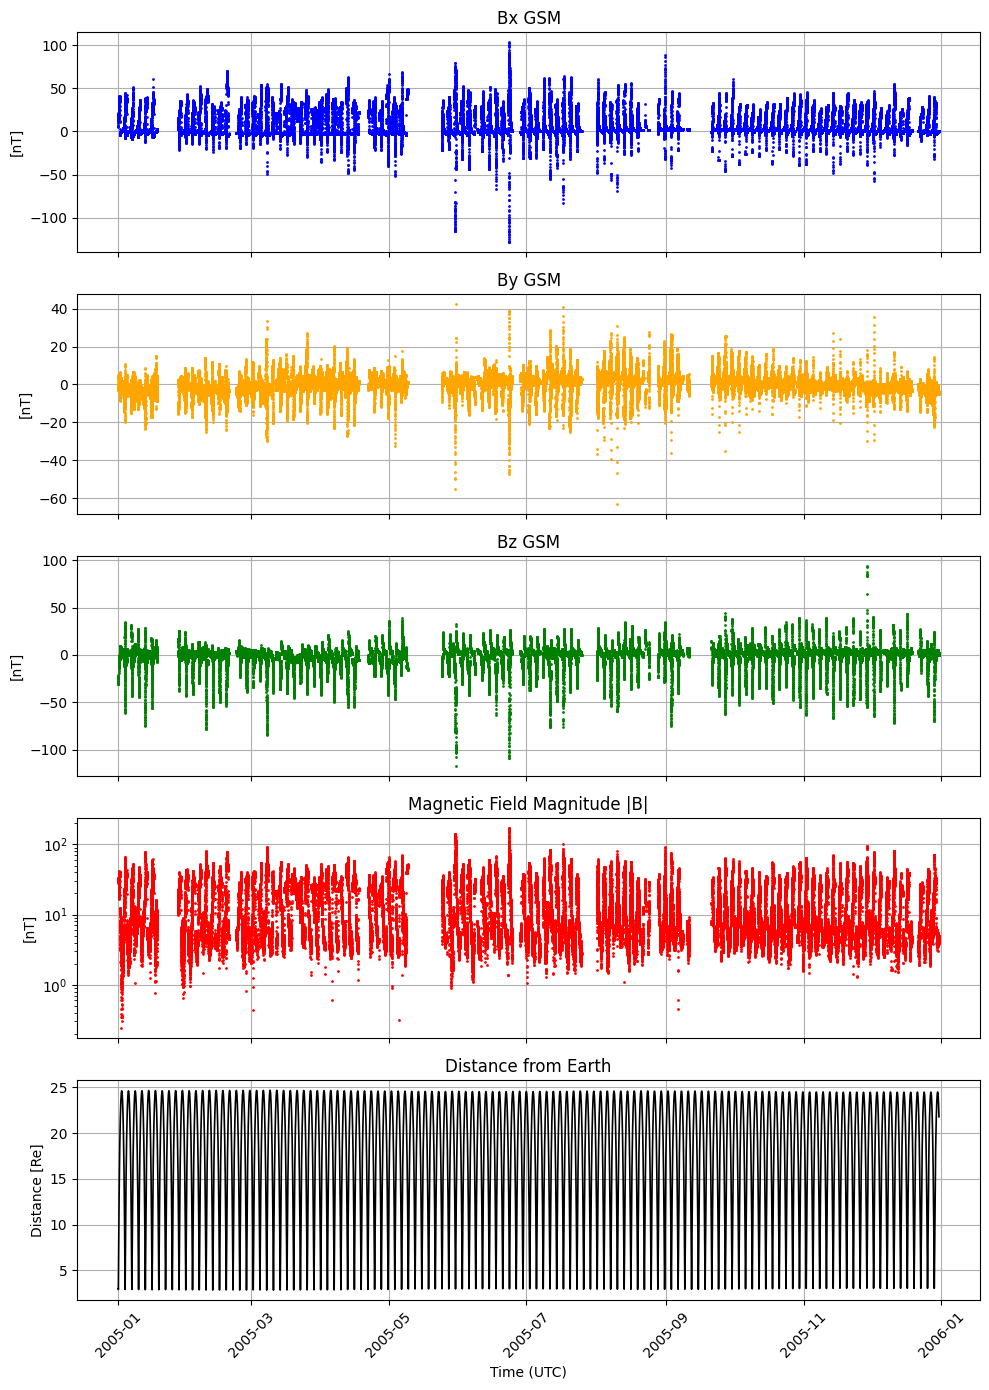

In [18]:
startdate = f'{startyear}-01-01 00:00'
enddate =  f'{endyear}-12-31 23:59'

df_short_input = input_df.loc[startdate:enddate].copy()
df_short_integral = df_prep_integral.loc[startdate:enddate].copy()

df_short_input = df_short_integral.merge(
    df_short_input,
    left_index=True,
    right_index=True,
    how='left'
)

total = len(df_short_input)
bx_list, by_list, bz_list, times = [], [], [], []

error_count = 0

for i, (idx, row) in enumerate(df_short_input.iterrows()):
    remaining = total - i
    if i % 5000 == 0:
        print(f"Processing {i}/{total}... {remaining} remaining, ({i/total:.2%})")

    dt = idx
    ut = int(time.mktime(dt.timetuple()))
    ps = geopack.recalc(ut)

    # T04 parameters
    par = [
        row["Ram_Pressure_nPa"],         # Pdyn
        row["SYM_H"],                    # Dst
        row["BY_GSM"], row["BZ_GSM"],   # IMF By, Bz
        row["W1"], row["W2"], row["W3"],
        row["W4"], row["W5"], row["W6"]
    ]
    xgsm = row["x_gsm_re"]
    ygsm = row["y_gsm_re"]
    zgsm = row["z_gsm_re"]


    bxgsm, bygsm, bzgsm = t04.t04(par, ps, xgsm, ygsm, zgsm)
    if np.isnan(bxgsm) or np.isnan(bygsm) or np.isnan(bzgsm):
        error_count += 1
        bxgsm = bygsm = bzgsm = np.nan
    bx_list.append(bxgsm)
    by_list.append(bygsm)
    bz_list.append(bzgsm)
    times.append(dt)
    

print(f"Total NA values encountered in magnetic field: {error_count}")
if error_count > 0:
    print(f"Unavailable data: {error_count / total:.2%}")
else:
    print(f"Unavailable data: 0.00%")

b_magnitude = np.sqrt(np.array(bx_list)**2 + np.array(by_list)**2 + np.array(bz_list)**2)


df_output = pd.DataFrame({ 
    'time': times,
    'bx_gsm': bx_list,
    'by_gsm': by_list,
    'bz_gsm': bz_list,
    'b_magnitude': b_magnitude,
})

# Create 5 vertically stacked subplots
fig, axs = plt.subplots(5, 1, figsize=(10, 14), sharex=True)

r_distance = df_short_input['distance'].values

# --- Plot Bx ---
axs[0].plot(df_output['time'], df_output['bx_gsm'], 
            marker='o', markersize=1, linewidth=0, color='blue')
axs[0].set_ylabel('[nT]')
axs[0].set_title('Bx GSM')
axs[0].grid(True)

# --- Plot By ---
axs[1].plot(df_output['time'], df_output['by_gsm'], 
            marker='o', markersize=1, linewidth=0, color='orange')
axs[1].set_ylabel('[nT]')
axs[1].set_title('By GSM')
axs[1].grid(True)

# --- Plot Bz ---
axs[2].plot(df_output['time'], df_output['bz_gsm'], 
            marker='o', markersize=1, linewidth=0, color='green')
axs[2].set_ylabel('[nT]')
axs[2].set_title('Bz GSM')
axs[2].grid(True)

# --- Plot |B| ---
axs[3].plot(df_output['time'], df_output['b_magnitude'], 
            marker='o', markersize=1, linewidth=0, color='red')
axs[3].set_ylabel('[nT]')
axs[3].set_title('Magnetic Field Magnitude |B|')
axs[3].set_yscale('log', base=10)
axs[3].grid(True)

# --- Plot Distance (only) ---
axs[4].plot(df_output['time'], r_distance, 
            color='black', linewidth=1.2)
axs[4].set_ylabel('Distance [Re]')
axs[4].set_title('Distance from Earth')
axs[4].set_xlabel('Time (UTC)')
axs[4].grid(True)

# --- Formatting ---
axs[4].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()



Save and load the data in .hdf5 format

In [ ]:
df_output['r_distance'] = r_distance
df_output.to_hdf('./magfield_data_full.h5',
              key="df",
              mode="w",
              format='table',
              complevel=1)

In [ ]:
loaded_df = pd.read_hdf('./magfield_data_full.h5', key="df", mode="r")

loaded_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2347331 entries, 0 to 2347330
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   time         datetime64[ns]
 1   bx_gsm       float64       
 2   by_gsm       float64       
 3   bz_gsm       float64       
 4   b_magnitude  float64       
 5   r_distance   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 125.4 MB


In [ ]:
loaded_df.head(10)

,time,bx_gsm,by_gsm,bz_gsm,b_magnitude,r_distance
0,2002-10-17 05:45:00,-1.936223,1.995626,-31.222942,31.346508,1.130973
1,2002-10-17 05:50:00,5.366856,-3.565792,-29.003751,29.710867,1.118993
2,2002-10-17 05:55:00,9.396814,-1.985973,-28.377173,29.958440,1.198198
3,2002-10-17 06:00:00,8.892436,-1.964054,-28.993657,30.390213,1.351132
4,2002-10-17 06:05:00,9.060057,-4.413688,-30.588328,32.205762,1.551394
5,2002-10-17 06:10:00,10.054377,-4.099360,-31.444054,33.265955,1.774700
6,2002-10-17 06:15:00,10.851967,-3.930268,-32.433340,34.425771,2.005647
7,2002-10-17 06:20:00,11.482992,-2.622986,-32.017270,34.115169,2.238310
8,2002-10-17 06:25:00,11.425495,-2.761609,-32.462685,34.525271,2.469410
9,2002-10-17 06:30:00,10.515063,-0.867639,-31.288063,33.019119,2.700510
